# SIGReg Masking and View Strategy (`train.py` + `tune.py`)

This notebook documents the **current implementation** of spectrum masking and two-view construction used by pretraining.

Coverage:
- `PeakSetSIGReg._augment_view` (masked view) and `_augment_unmasked_view` (jitter-only view)
- how the two views are fused in `forward()`
- how `train.py` consumes the resulting metrics
- how `tune.py` names/handles related hyperparameters

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from input_pipeline import TfLightningDataModule, numpy_batch_to_torch
from utils.training import load_config, build_model_from_config
from tune import generate_trial_configs, build_trial_run_name, _PARAM_ABBREVS

tf.config.set_visible_devices([], 'GPU')
sns.set_theme(style='whitegrid')
torch.set_printoptions(precision=4, sci_mode=False)

2026-02-12 10:31:11.486004: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-12 10:31:11.517542: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-12 10:31:12.460853: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/tqdm

## 1. Load config + instantiate model

In [2]:
cfg = load_config('../configs/gems_a_50_mask.py')
cfg.tfrecord_dir = "../" + cfg.tfrecord_dir
model = build_model_from_config(cfg).eval()
strategy_cfg = {
    'sigreg_contiguous_mask_fraction': float(cfg.sigreg_contiguous_mask_fraction),
    'sigreg_contiguous_mask_min_len': int(cfg.sigreg_contiguous_mask_min_len),
    'sigreg_mz_jitter_std': float(cfg.sigreg_mz_jitter_std),
    'sigreg_intensity_jitter_std': float(cfg.sigreg_intensity_jitter_std),
    'num_peaks': int(cfg.num_peaks),
    'peak_ordering': str(cfg.peak_ordering),
}
strategy_cfg

{'sigreg_contiguous_mask_fraction': 0.35,
 'sigreg_contiguous_mask_min_len': 1,
 'sigreg_mz_jitter_std': 0.001,
 'sigreg_intensity_jitter_std': 0.1,
 'num_peaks': 60,
 'peak_ordering': 'mz'}

## 2. Pull one real batch from the current TF pipeline

In [3]:
seed = int(cfg.seed)
dm = TfLightningDataModule(cfg, seed=seed)
probe_ds = dm.build_massspec_probe_dataset('massspec_train', seed=seed, peak_ordering=cfg.probe_peak_ordering)
np_batch = next(probe_ds.as_numpy_iterator())
batch = numpy_batch_to_torch(np_batch)

{k: tuple(v.shape) if isinstance(v, torch.Tensor) else type(v) for k, v in batch.items()}

2026-02-12 10:31:15.583774: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 250000


{'rt': (512,),
 'precursor_mz': (512,),
 'fingerprint': (512, 1024),
 'adduct_id': (512,),
 'instrument_type_id': (512,),
 'collision_energy': (512,),
 'collision_energy_present': (512,),
 'peak_valid_mask': (512, 60),
 'peak_mz': (512, 60),
 'peak_intensity': (512, 60)}

In [4]:
valid_counts = batch['peak_valid_mask'].sum(dim=1)
sample_idx = int(torch.argmax(valid_counts).item())
print('Selected sample index:', sample_idx)
print('Valid peaks in selected sample:', int(valid_counts[sample_idx]))

Selected sample index: 1
Valid peaks in selected sample: 60


## 3. Helper functions for sorted-span checks and plotting

In [5]:
def sorted_span_for_sample(peak_mz, peak_valid_mask, row):
    valid_idx = torch.nonzero(peak_valid_mask[row], as_tuple=False).squeeze(-1)
    sorted_valid_idx = valid_idx[torch.argsort(peak_mz[row, valid_idx])]
    start, end = 0, int(max(sorted_valid_idx.numel() - 1, 0))
    return sorted_valid_idx, int(start), int(end)

def contiguous_in_sorted_order(masked_row, sorted_valid_idx):
    pos = torch.nonzero(masked_row[sorted_valid_idx], as_tuple=False).squeeze(-1)
    if pos.numel() <= 1:
        return True, pos
    return bool(torch.all(pos[1:] - pos[:-1] == 1)), pos

def plot_three_views(orig_mz, orig_int, valid, v1_mz, v1_int, v1_masked, v2_mz, v2_int, title=''):
    x = torch.arange(orig_mz.shape[0])
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    axes[0].bar(x[valid], orig_int[valid].cpu().numpy(), color='#3B82F6', alpha=0.8)
    axes[0].set_title('Original intensity (valid peaks only)')

    jitterable = valid & (~v1_masked)
    axes[1].bar(x[jitterable], v1_int[jitterable].cpu().numpy(), color='#10B981', alpha=0.8, label='jittered')
    axes[1].bar(x[v1_masked], torch.ones_like(v1_int[v1_masked]).cpu().numpy() * 0.02, color='#EF4444', alpha=0.9, label='masked')
    axes[1].set_title('View 1: masked + jittered')
    axes[1].legend(loc='upper right')

    axes[2].bar(x[valid], v2_int[valid].cpu().numpy(), color='#F59E0B', alpha=0.8)
    axes[2].set_title('View 2: unmasked jitter-only')

    axes[2].set_xlabel('Peak slot index')
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    plt.show()

## 4. Generate both views from the real model methods

In [6]:
torch.manual_seed(123)
v1_mz, v1_int, v1_valid, v1_masked, masked_fraction, density_interval_fraction = model._augment_view(
    batch['peak_mz'], batch['peak_intensity'], batch['peak_valid_mask']
)
v2_mz, v2_int, v2_valid, v2_masked = model._augment_unmasked_view(
    batch['peak_mz'], batch['peak_intensity'], batch['peak_valid_mask']
)

print('masked_fraction:', float(masked_fraction))
print('density_interval_fraction:', float(density_interval_fraction))
print('masked positions in view2:', int(v2_masked.sum()))

masked_fraction: 0.36334264278411865
density_interval_fraction: 1.0
masked positions in view2: 0


In [7]:
batch['peak_valid_mask'][row]

NameError: name 'row' is not defined

In [8]:
batch['peak_intensity'][row]

NameError: name 'row' is not defined

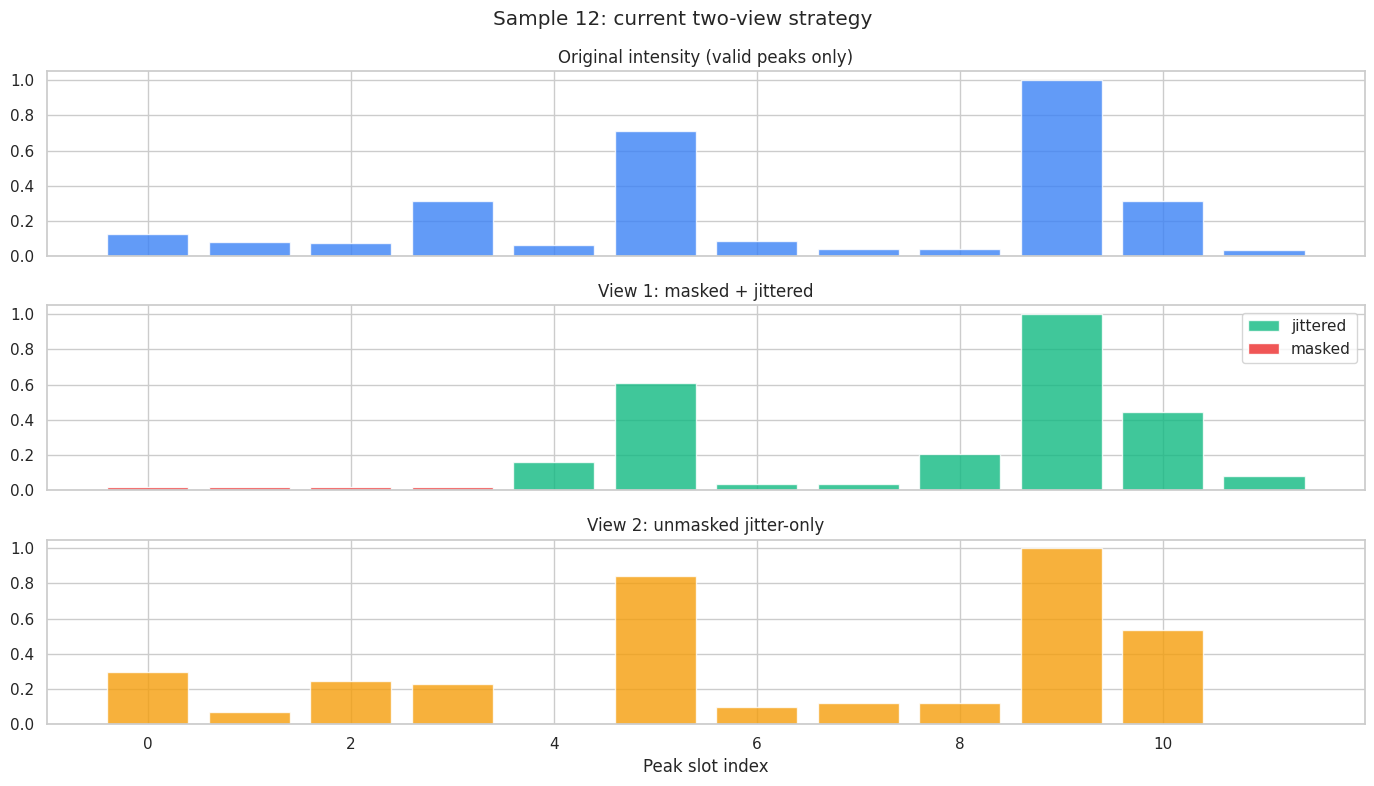

In [9]:
row = 12
plot_three_views(
    batch['peak_mz'][row],
    batch['peak_intensity'][row],
    batch['peak_valid_mask'][row],
    v1_mz[row],
    v1_int[row],
    v1_masked[row],
    v2_mz[row],
    v2_int[row],
    title=f'Sample {row}: current two-view strategy',
)

## 5. Inspect contiguity and density-interval constraints

In [10]:
row = sample_idx
sorted_valid_idx, interval_start, interval_end = sorted_span_for_sample(
    batch['peak_mz'], batch['peak_valid_mask'], row
)
is_contiguous, masked_pos = contiguous_in_sorted_order(v1_masked[row], sorted_valid_idx)

print('Sorted valid span in mz order:', (interval_start, interval_end))
print('Masked positions (in mz-sorted valid peaks):', masked_pos.tolist())
print('Contiguous mask in sorted order:', is_contiguous)

if masked_pos.numel() > 0:
    print('Mask inside sorted valid span:', int(masked_pos.min()) >= interval_start and int(masked_pos.max()) <= interval_end)

Sorted valid span in mz order: (0, 59)
Masked positions (in mz-sorted valid peaks): [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
Contiguous mask in sorted order: True
Mask inside sorted valid span: True


In [11]:
all_contiguous = []
all_inside_span = []
for r in range(v1_masked.shape[0]):
    sorted_valid_idx, s, e = sorted_span_for_sample(batch['peak_mz'], batch['peak_valid_mask'], r)
    contiguous, pos = contiguous_in_sorted_order(v1_masked[r], sorted_valid_idx)
    all_contiguous.append(contiguous)
    if pos.numel() == 0:
        all_inside_span.append(True)
    else:
        all_inside_span.append(int(pos.min()) >= s and int(pos.max()) <= e)

print('All rows contiguous:', all(all_contiguous))
print('All rows masked inside sorted valid span:', all(all_inside_span))
print('Masked subset of valid:', bool((v1_masked <= batch['peak_valid_mask']).all()))

All rows contiguous: True
All rows masked inside sorted valid span: True
Masked subset of valid: True


## 6. Batch-level behavior over repeated stochastic augmentations

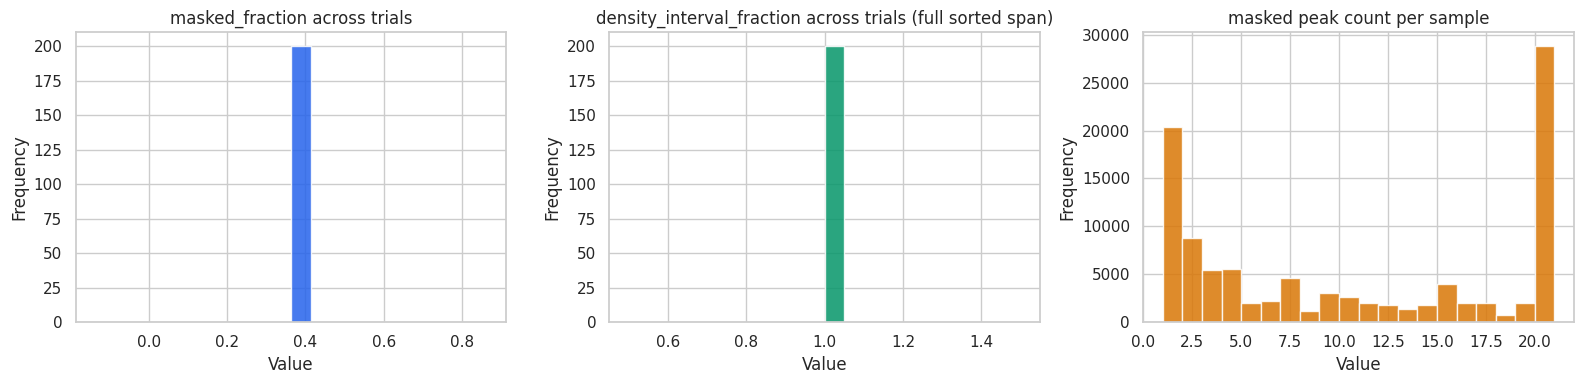

masked_fraction mean/std: 0.36334264278411865 0.0
density_interval_fraction mean/std (full sorted span): 1.0 0.0


In [12]:
num_trials = 200
masked_fraction_hist = []
density_fraction_hist = []
masked_count_hist = []

for t in range(num_trials):
    torch.manual_seed(10_000 + t)
    _, _, _, masked, mf, df = model._augment_view(batch['peak_mz'], batch['peak_intensity'], batch['peak_valid_mask'])
    masked_fraction_hist.append(float(mf))
    density_fraction_hist.append(float(df))
    per_row_counts = masked.sum(dim=1).float()
    masked_count_hist.extend(per_row_counts.tolist())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(masked_fraction_hist, bins=20, color='#2563EB', alpha=0.85)
axes[0].set_title('masked_fraction across trials')

axes[1].hist(density_fraction_hist, bins=20, color='#059669', alpha=0.85)
axes[1].set_title('density_interval_fraction across trials (full sorted span)')

axes[2].hist(masked_count_hist, bins=20, color='#D97706', alpha=0.85)
axes[2].set_title('masked peak count per sample')

for ax in axes:
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print('masked_fraction mean/std:', np.mean(masked_fraction_hist), np.std(masked_fraction_hist))
print('density_interval_fraction mean/std (full sorted span):', np.mean(density_fraction_hist), np.std(density_fraction_hist))

## 7. `forward()` view fusion and train-time metrics

In [11]:
torch.manual_seed(321)
view1_mz, view1_int, view1_valid, view1_masked, view1_masked_fraction, view1_density_fraction = model._augment_view(
    batch['peak_mz'], batch['peak_intensity'], batch['peak_valid_mask']
)
view2_mz, view2_int, view2_valid, view2_masked = model._augment_unmasked_view(
    batch['peak_mz'], batch['peak_intensity'], batch['peak_valid_mask']
)

fused_mz = torch.cat([view1_mz, view2_mz], dim=0)
fused_int = torch.cat([view1_int, view2_int], dim=0)
fused_precursor = torch.cat([batch['precursor_mz'], batch['precursor_mz']], dim=0)
fused_valid = torch.cat([view1_valid, view2_valid], dim=0)
fused_masked = torch.cat([view1_masked, view2_masked], dim=0)

print('fused_mz shape:', tuple(fused_mz.shape))
print('fused_valid shape:', tuple(fused_valid.shape))
print('masked count view1:', int(view1_masked.sum().item()))
print('masked count view2:', int(view2_masked.sum().item()))
print('masked count fused second half:', int(fused_masked[batch['peak_mz'].shape[0]:].sum().item()))

fused_mz shape: (1024, 60)
fused_valid shape: (1024, 60)
masked count view1: 3144
masked count view2: 0
masked count fused second half: 0


In [12]:
projection = model.sample_bcs_projection(device=batch['peak_mz'].device, seed=7)
torch.manual_seed(777)
metrics = model(batch, train=True, bcs_projection=projection)

metric_keys = [
    'loss',
    'bcs_loss',
    'invariance_loss',
    'valid_fraction',
    'masked_fraction',
    'density_interval_fraction',
    'representation_variance',
]

for k in metric_keys:
    print(f'{k:>25}: {float(metrics[k].detach()):.6f}')

                     loss: 0.065207
                 bcs_loss: 0.403130
          invariance_loss: 0.024894
           valid_fraction: 1.000000
          masked_fraction: 0.102344
density_interval_fraction: 1.000000
  representation_variance: 0.045029


`train.py` logs the same fields during pretraining (`train/loss`, `train/masked_fraction`, `train/density_interval_fraction`, etc.). `density_interval_fraction` now reflects the full sorted valid m/z span.

## 8. `tune.py` integration for masking-related hyperparameters

In [13]:
print('Current tune_param_space from config:')
print(list(cfg.tune_param_space))
print()
print('Mask/view-related abbreviations in tune.py:')
for key in sorted(_PARAM_ABBREVS):
    if 'mask' in key:
        print(f'  {key} -> {_PARAM_ABBREVS[key]}')

Current tune_param_space from config:
[{'param': 'sigreg_lambda', 'dist': 'grid', 'args': [10.0, 20.0]}]

Mask/view-related abbreviations in tune.py:
  sigreg_contiguous_mask_fraction -> cmf


In [14]:
example_space = [
    {'param': 'sigreg_contiguous_mask_fraction', 'dist': 'grid', 'args': [0.15, 0.25]},
]
trial_cfgs = generate_trial_configs(example_space, num_samples=1, seed=42)
for idx, trial in enumerate(trial_cfgs):
    print(build_trial_run_name(idx, trial), trial)

tune-000-cmf=0.15 {'sigreg_contiguous_mask_fraction': 0.15}
tune-001-cmf=0.25 {'sigreg_contiguous_mask_fraction': 0.25}


## 9. Summary

The current strategy is:
1. Build two views per spectrum: **masked+jittered** view and **unmasked jitter-only** view.
2. In the masked view, sort valid peaks by m/z and treat the full valid sorted span as eligible, then mask a contiguous sub-span with length controlled by `sigreg_contiguous_mask_fraction` and `sigreg_contiguous_mask_min_len`.
3. Replace masked positions with a learned `mask_token` inside the encoder while non-masked valid positions are jittered and re-normalized.
4. Concatenate both views and run one fused encoder/pool/projector pass, then apply SIGReg loss on `(z1, z2)`.
5. `tune.py` can sweep masking-related hyperparameters and names runs using short abbreviations (`cmf`).